---
title: "Sequences"
mathjax: true
toc: true
toc_sticky: true
categories: [data science, statistics]
---

This is the first in a series of posts about transformers.

Planning / ToC:
- data
- tokenization
- setting up tensors
- datasplits, batching
- sequences
- simple baseline model (bigram)


- running in scripts
- attention
- basic pytorch commands?
- what are we predicting?

In [13]:
import torch
import seaborn as sns
from smart_open import open

In [14]:
sns.set_context("talk")
sns.set_palette("colorblind")
cb_palette = sns.color_palette()

# The Shakespeare dataset

Why this as a teaching example? Common, open-source, intuitive for someone to understand

Real world dataset: The internet

In [15]:
# Inspect this link directly in the browser to see the data:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = open(DATA_URL, "r").read()

# See the first 300 characters of the data:
print(text[0:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


# Character level tokenization

Why this as a teaching example? Simple, limited vocabulary

Real world: tokenizers like ...  yields very high vocabulary (xx number of tokens)

From this corpus, we're able to derive a very simple vocabulary. Note that I'm showing the list of `chars` here so you can see special characters like newlines and spaces are part of the vocabulary.

In [16]:
chars = sorted(list(set(text)))
vocab_size = len(chars)


print(f"{vocab_size}\nunique characters: {chars}")

65
unique characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


# Tensor setup

## Why tensors? Why not strings, numpy matrices, etc.


In [17]:
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}


def encode(s):
    """Take a string, output a list of integers."""
    return [stoi[c] for c in s]


def decode(l):
    """Take a list of integers, output a string."""
    return "".join([itos[i] for i in l])


print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


Modern tokenizers include Google SentencePiece, OpenAI tiktoken.

 Now tokenize the entire dataset. Why are we wrapping our tokens into a `torch.tensor` object? Practically, it plays nice with numpy or pandas, it can be moved to a GPU easily (`x.to('cuda')`), makes backpropagation calculation easy.

 Note that specifying `dtype=torch.long` makes the data type integer. The pytorch default is `float32` so constraining to integer is good practice to save memory.

In [18]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:200])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59])


In [19]:
# Look again how the data looks as integers, and then decode it back to characters to sanity check
print(" ".join(map(str, data.tolist()))[0:100])
print(" ".join(decode(data.tolist()))[0:100])

18 47 56 57 58 1 15 47 58 47 64 43 52 10 0 14 43 44 53 56 43 1 61 43 1 54 56 53 41 43 43 42 1 39 52 
F i r s t   C i t i z e n : 
 B e f o r e   w e   p r o c e e d   a n y   f u r t h e r ,   h e a r 


## Data splits

In [20]:
# Split data into train and validation tensor objects
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

## Blocking and batching

### Blocking (or context length)

It's very computationally expensive to train the transformer by feeding it the whole text. Instead feed it chunks (or blocks) which is more computationally feasible.

In code, the maximum length of a chunk of data has to be specified. Here we'll call it `block_size` but it might be referred to as `context_length` in other documentation. 

In [21]:
block_size = 8

# We add a plus one so that we can have a target character for the last input character in the block
train_data[: block_size + 1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

When we sample like this, it actually has multiple examples packed into it since every character follows each other. In this set of 9 tokens, there are 8 training examples. During training, each token in this block will have its own set of tokens behind it as a training example. In this way, there are at least two benefits: (1) the training will be more efficient and (2) the model will get used to seeing examples of different sizes.

In [22]:
x = train_data[:block_size]
y = train_data[1 : block_size + 1]
for t in range(block_size):
    context = x[: t + 1]
    target = y[t]
    print(f"When input is {context} target is: {target}")

When input is tensor([18]) target is: 47
When input is tensor([18, 47]) target is: 56
When input is tensor([18, 47, 56]) target is: 57
When input is tensor([18, 47, 56, 57]) target is: 58
When input is tensor([18, 47, 56, 57, 58]) target is: 1
When input is tensor([18, 47, 56, 57, 58,  1]) target is: 15
When input is tensor([18, 47, 56, 57, 58,  1, 15]) target is: 47
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) target is: 58


What if your input size is longer than block size? In this simple architecture, you'd have to truncate the input.

### Batching

Batching is stacking up multiple blocks of data into a tensor that is capable of being fed into a GPU if available. This is done for efficiency and to keep the GPUs busy since a lot of parallel processing can happen without the data talking or interacting with each other.

The code below is generalizing the above loop for a batch of data.

In [23]:
# torch.manual_seed(1337)
torch.manual_seed(9999)
batch_size = 4  # how many independent sequences will we process in parallel?
block_size = 8  # what is the maximum context length for predictions?


def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == "train" else val_data
    # ix will return a tensor where values are randomly chosen between 
    # 0 and len(data) - block_size and the 
    # shape of the tensor will be (batch_size,)
    ix = torch.randint(len(data) - block_size, (batch_size,)) 

    # then it will get each block of training data 
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x, y


xb, yb = get_batch("train")
print("inputs:")
print(xb.shape)
print(f"xb:\n {xb}")

print("targets:")
print(yb.shape)
print(f"yb:\n {yb}")

inputs:
torch.Size([4, 8])
xb:
 tensor([[ 1, 57, 47, 52, 57,  1, 51, 53],
        [43, 42, 43, 51, 54, 58, 47, 53],
        [53, 59,  1, 56, 59, 52,  1, 57],
        [56,  7, 57, 59, 47, 58, 43, 42]])
targets:
torch.Size([4, 8])
yb:
 tensor([[57, 47, 52, 57,  1, 51, 53, 57],
        [42, 43, 51, 54, 58, 47, 53, 52],
        [59,  1, 56, 59, 52,  1, 57, 53],
        [ 7, 57, 59, 47, 58, 43, 42,  1]])


In [24]:
len(train_data) - block_size

1003846

In [25]:
torch.randint(len(data) - block_size, (batch_size,)) 

tensor([162309, 283811, 193658, 667105])

In [26]:
for b in range(batch_size):  # batch dimension
    for t in range(block_size):  # time dimension
        context = xb[b, :t + 1]
        target = yb[b, t]

        print(f"When input is {context.tolist()} the target is: {target}")

When input is [1] the target is: 57
When input is [1, 57] the target is: 47
When input is [1, 57, 47] the target is: 52
When input is [1, 57, 47, 52] the target is: 57
When input is [1, 57, 47, 52, 57] the target is: 1
When input is [1, 57, 47, 52, 57, 1] the target is: 51
When input is [1, 57, 47, 52, 57, 1, 51] the target is: 53
When input is [1, 57, 47, 52, 57, 1, 51, 53] the target is: 57
When input is [43] the target is: 42
When input is [43, 42] the target is: 43
When input is [43, 42, 43] the target is: 51
When input is [43, 42, 43, 51] the target is: 54
When input is [43, 42, 43, 51, 54] the target is: 58
When input is [43, 42, 43, 51, 54, 58] the target is: 47
When input is [43, 42, 43, 51, 54, 58, 47] the target is: 53
When input is [43, 42, 43, 51, 54, 58, 47, 53] the target is: 52
When input is [53] the target is: 59
When input is [53, 59] the target is: 1
When input is [53, 59, 1] the target is: 56
When input is [53, 59, 1, 56] the target is: 59
When input is [53, 59, 1, 5

Now feed these into a transformer.

# Bigram Language Model

See [his video](https://www.youtube.com/watch?v=PaCmpygFfXo) more details.

Why this as a teaching example? Literally use only current (one) character to predict the next (and only one) character.

Real world: tokenizers like ...  yields very high vocabulary (xx number of tokens)

Before going into the model, let's explain some pytorch functions. Let's start with `nn.Embedding`. We'll initialize it with two parameters, each will be `vocab_size`. The first one represents the input, since we need a row for each input token. The second `vocab_size` represents the output, which is every possible next token. The values of the embedding table itself start off as random but then will be learned during back propagation.

In [39]:
print(nn.Embedding(vocab_size, vocab_size).weight.shape)

# Inspect the values
# .detach removes gradient tracking, .cpu moves the tensor to CPU memory, .numpy converts into numpy array
nn.Embedding(vocab_size, vocab_size).weight.detach().cpu().numpy()

torch.Size([65, 65])


array([[-1.1804545 ,  1.2799107 , -0.576272  , ...,  0.51713574,
         1.1132882 , -0.01418285],
       [-1.5026909 ,  1.0225196 , -0.70245224, ...,  0.26045805,
         0.2010661 ,  0.7309389 ],
       [-1.0242366 ,  0.25073686, -0.6268146 , ..., -0.45629394,
         0.91127455, -0.929049  ],
       ...,
       [ 0.56943256,  0.04380922, -0.7005937 , ...,  0.7094754 ,
        -0.21281725,  0.9867209 ],
       [ 1.8866227 ,  0.62820715, -0.8616563 , ...,  0.6623642 ,
        -0.6043916 ,  0.362292  ],
       [-0.54630786,  0.5200663 , -0.17499748, ..., -1.8638365 ,
        -0.04304413, -0.604716  ]], shape=(65, 65), dtype=float32)

In [ ]:
# using a simple NN, the bigram language model

import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets):
        # idx and targets are both (B, T) tensor of integers
        # for each idx, it is plucking out the idx-th row out of that embedding table
        
        # logits is shape (B,T,C) 
        logits = self.token_embedding_table(idx)

        # targets not used yet but will be used later to compute loss function

        return logits



torch.Size([4, 8, 65])


Then we'll pass in `xb` which we already defined above as our batch of training data. It will get processed through the forward function, which simply returns another embedding.

In [46]:
m = BigramLanguageModel(vocab_size) # initialize the model
out = m(xb, yb) # pass in the input and targets to the model, but targets not used yet
print(out.shape) # for each example (B) and time step (T), return an embedding (C) 

torch.Size([4, 8, 65])


In [45]:
m

BigramLanguageModel(
  (token_embedding_table): Embedding(65, 65)
)

In [40]:
xb

tensor([[ 1, 57, 47, 52, 57,  1, 51, 53],
        [43, 42, 43, 51, 54, 58, 47, 53],
        [53, 59,  1, 56, 59, 52,  1, 57],
        [56,  7, 57, 59, 47, 58, 43, 42]])

In [47]:
out

tensor([[[ 0.8268, -0.4552,  1.9175,  ...,  1.1968,  0.6713, -0.3283],
         [ 0.3120,  0.6893,  2.2240,  ..., -0.7444, -0.9024, -0.9497],
         [ 1.3827, -1.0338, -2.7436,  ..., -0.0545,  0.6631,  0.0531],
         ...,
         [ 0.8268, -0.4552,  1.9175,  ...,  1.1968,  0.6713, -0.3283],
         [-1.6702, -1.1853, -1.1224,  ...,  0.2519,  1.0485, -2.5036],
         [ 0.3145, -0.6442,  1.0490,  ..., -0.5600, -2.0788, -0.5357]],

        [[ 0.2705, -0.4544, -0.9675,  ...,  0.4451,  0.1394, -0.6808],
         [-0.6247, -1.4613, -0.0990,  ...,  0.8454,  0.7094,  1.5344],
         [ 0.2705, -0.4544, -0.9675,  ...,  0.4451,  0.1394, -0.6808],
         ...,
         [ 0.4585,  0.3150, -1.2076,  ...,  0.0976, -1.5793,  0.2830],
         [ 1.3827, -1.0338, -2.7436,  ..., -0.0545,  0.6631,  0.0531],
         [ 0.3145, -0.6442,  1.0490,  ..., -0.5600, -2.0788, -0.5357]],

        [[ 0.3145, -0.6442,  1.0490,  ..., -0.5600, -2.0788, -0.5357],
         [-2.0802,  1.6506, -0.8394,  ..., -0

Now what does each B,T set of embedding values represents? The logits which will eventually be passed to softmax to give us the probability of each token.

In [48]:
out[0, 0, :]

tensor([ 8.2684e-01, -4.5517e-01,  1.9175e+00, -4.8854e-01, -1.0699e+00,
         5.2071e-01, -1.4470e+00,  1.3111e+00,  2.1824e+00, -5.1753e-01,
        -5.0865e-02, -4.7849e-01,  1.0375e+00,  8.0628e-01, -1.6247e+00,
        -1.0393e+00, -4.2442e-01,  1.0035e+00,  5.6747e-01,  3.8757e-01,
        -6.3029e-01, -3.9035e-01,  4.4251e-01,  8.6746e-02,  9.8137e-01,
         2.2038e-01,  3.2353e-01, -1.2319e+00, -6.1533e-01, -8.0929e-01,
         1.8925e-01,  1.3834e+00, -5.5775e-01, -7.0132e-01,  4.8152e-01,
         1.7489e+00,  8.5938e-01,  1.4901e+00,  1.7494e-01,  3.6738e-01,
        -1.2367e-03, -1.3254e+00,  2.3182e-01, -1.3939e+00,  1.1542e+00,
         5.8248e-01,  2.6842e+00, -8.4565e-01,  5.4842e-01, -5.1453e-02,
        -1.2592e+00,  8.9668e-01, -1.6835e+00, -1.0846e-02, -6.3657e-01,
        -2.2772e+00,  7.6325e-01,  1.3149e+00,  4.3545e-01,  3.2095e-01,
         1.3420e+00, -5.9074e-02,  1.1968e+00,  6.7132e-01, -3.2825e-01],
       grad_fn=<SelectBackward0>)

<BarContainer object of 65 artists>

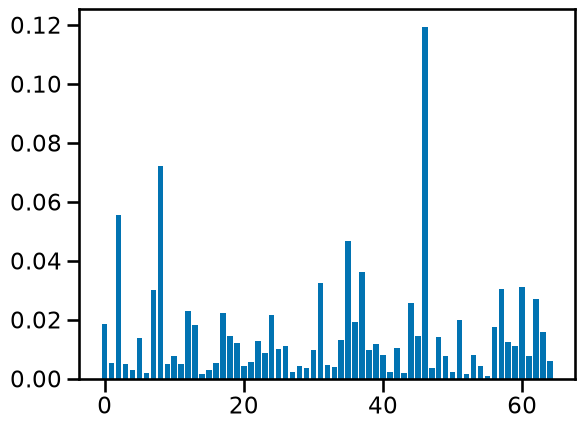

In [56]:
from scipy.special import softmax
from matplotlib import pyplot as plt

plt.bar(x=range(len(softmax(out[0, 0, :].detach().cpu().numpy()))), height=softmax(out[0, 0, :].detach().cpu().numpy()))

Right now the probabilities of reach token are generally low. It makes sense since the model hasn't learned anything. Let's move towards that by introducing the loss function.

# Cross-entropy as the loss function

Let's first look at how cross-entropy is calculated with `scipy` then see how PyTorch runs this under the hood with a simpler inputs.

In [57]:
# understanding cross entropy
logits_example = torch.tensor([
    [1.5, 0.2, 3.1], # scores for 'a', 'b', 'c' — correct answer is 'c' (index 2), and 3.1 is highest ✓
    [2.0, 0.5, 0.1] # scores for 'a', 'b', 'c' — correct answer is 'a' (index 0), and 2.0 is highest ✓
    ])

logits_example

tensor([[1.5000, 0.2000, 3.1000],
        [2.0000, 0.5000, 0.1000]])

In [58]:
targets_example = torch.tensor([2, 0])  # meaning: correct answer is 'c', then correct answer is 'a'
targets_example

tensor([2, 0])

In [28]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Tue, 16 Jun 2026

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.14.1

seaborn   : 0.13.2
smart_open: 7.6.1
torch     : 2.12.0

Watermark: 2.6.0

